In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install transformers torch -q

import pandas as pd
import numpy as np
import re
import pickle
import os
import json
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
nltk.download('stopwords')
from nltk.corpus import stopwords

# Plot style
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

print("✅ All imports done!")

✅ All imports done!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
path = "/content/drive/MyDrive/ML 2026/Text Model/twitter_toxic_tweets.csv"
df = pd.read_csv(path)

print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nLabel distribution:")
print(df['label'].value_counts())
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head()

Shape: (31962, 3)

Column names: ['id', 'label', 'tweet']

Label distribution:
label
0    29720
1     2242
Name: count, dtype: int64

Missing values:
id       0
label    0
tweet    0
dtype: int64


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


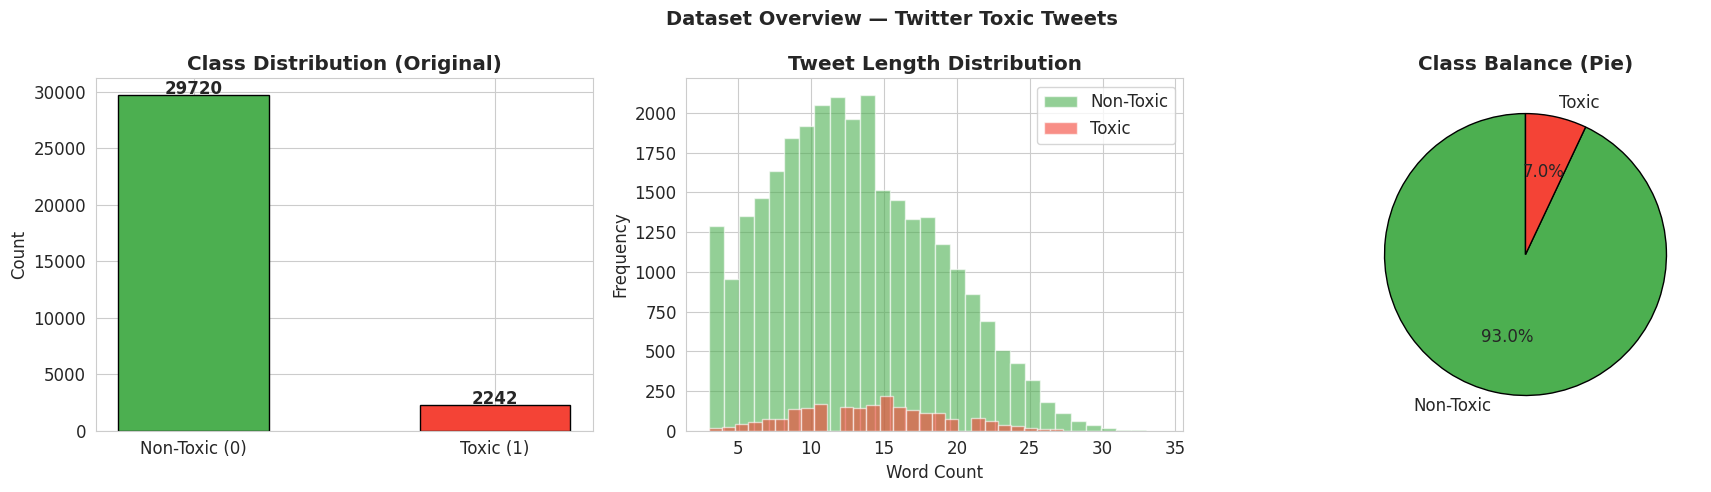

✅ Dataset overview saved!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 — Class distribution
counts = df['label'].value_counts()
axes[0].bar(['Non-Toxic (0)', 'Toxic (1)'], counts.values,
            color=['#4CAF50', '#f44336'], edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution (Original)', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Plot 2 — Tweet length distribution
df['tweet_length'] = df['tweet'].apply(lambda x: len(str(x).split()))
axes[1].hist(df[df['label']==0]['tweet_length'], bins=30, alpha=0.6,
             color='#4CAF50', label='Non-Toxic')
axes[1].hist(df[df['label']==1]['tweet_length'], bins=30, alpha=0.6,
             color='#f44336', label='Toxic')
axes[1].set_title('Tweet Length Distribution', fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# Plot 3 — Pie chart
axes[2].pie(counts.values, labels=['Non-Toxic', 'Toxic'],
            colors=['#4CAF50', '#f44336'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'black'})
axes[2].set_title('Class Balance (Pie)', fontweight='bold')

plt.suptitle('Dataset Overview — Twitter Toxic Tweets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dataset overview saved!")

In [ ]:
from sklearn.utils import resample

stop_words = set(stopwords.words('english'))

def clean_tweet(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean_tweet'] = df['tweet'].apply(clean_tweet)

# Balance
df_majority = df[df['label'] == 0]
df_minority = df[df['label'] == 1]
df_minority_upsampled = resample(df_minority, replace=True,
                                  n_samples=len(df_majority),
                                  random_state=42)
df_balanced = pd.concat([df_majority, df_minority_upsampled])
df_balanced['clean_tweet'] = df_balanced['tweet'].apply(clean_tweet)

print("Before balancing:", df['label'].value_counts().to_dict())
print("After balancing: ", df_balanced['label'].value_counts().to_dict())

Before balancing: {0: 29720, 1: 2242}
After balancing:  {0: 29720, 1: 29720}


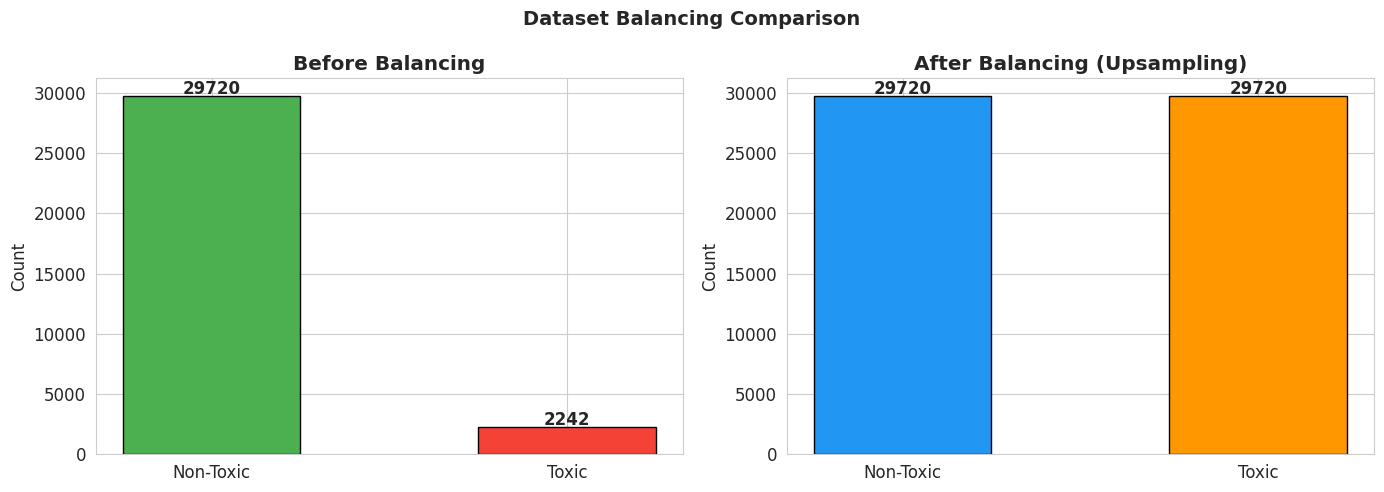

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
before = df['label'].value_counts()
axes[0].bar(['Non-Toxic', 'Toxic'], before.values,
            color=['#4CAF50', '#f44336'], edgecolor='black', width=0.5)
axes[0].set_title('Before Balancing', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(before.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# After
after = df_balanced['label'].value_counts()
axes[1].bar(['Non-Toxic', 'Toxic'], after.values,
            color=['#2196F3', '#FF9800'], edgecolor='black', width=0.5)
axes[1].set_title('After Balancing (Upsampling)', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(after.values):
    axes[1].text(i, v + 200, str(v), ha='center', fontweight='bold')

plt.suptitle('Dataset Balancing Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/balancing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = tfidf.fit_transform(df_balanced['clean_tweet'])
y = df_balanced['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape)
print("Test: ", X_test.shape)

Train: (47552, 5000)
Test:  (11888, 5000)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_curve, auc,
                              precision_recall_fscore_support)

lr = LogisticRegression(max_iter=1000, class_weight={0:1, 1:3}, C=0.5)
lr.fit(X_train, y_train)

lr_pred  = lr.predict(X_test)
lr_prob  = lr.predict_proba(X_test)[:, 1]
lr_acc   = accuracy_score(y_test, lr_pred)
lr_prec, lr_rec, lr_f1, _ = precision_recall_fscore_support(
    y_test, lr_pred, average='weighted')

print("── Logistic Regression ──")
print(f"Accuracy:  {lr_acc:.4f}")
print(f"Precision: {lr_prec:.4f}")
print(f"Recall:    {lr_rec:.4f}")
print(f"F1 Score:  {lr_f1:.4f}")
print()
print(classification_report(y_test, lr_pred,
      target_names=['Non-Toxic', 'Toxic']))

── Logistic Regression ──
Accuracy:  0.9191
Precision: 0.9302
Recall:    0.9191
F1 Score:  0.9186

              precision    recall  f1-score   support

   Non-Toxic       1.00      0.84      0.91      5944
       Toxic       0.86      1.00      0.93      5944

    accuracy                           0.92     11888
   macro avg       0.93      0.92      0.92     11888
weighted avg       0.93      0.92      0.92     11888



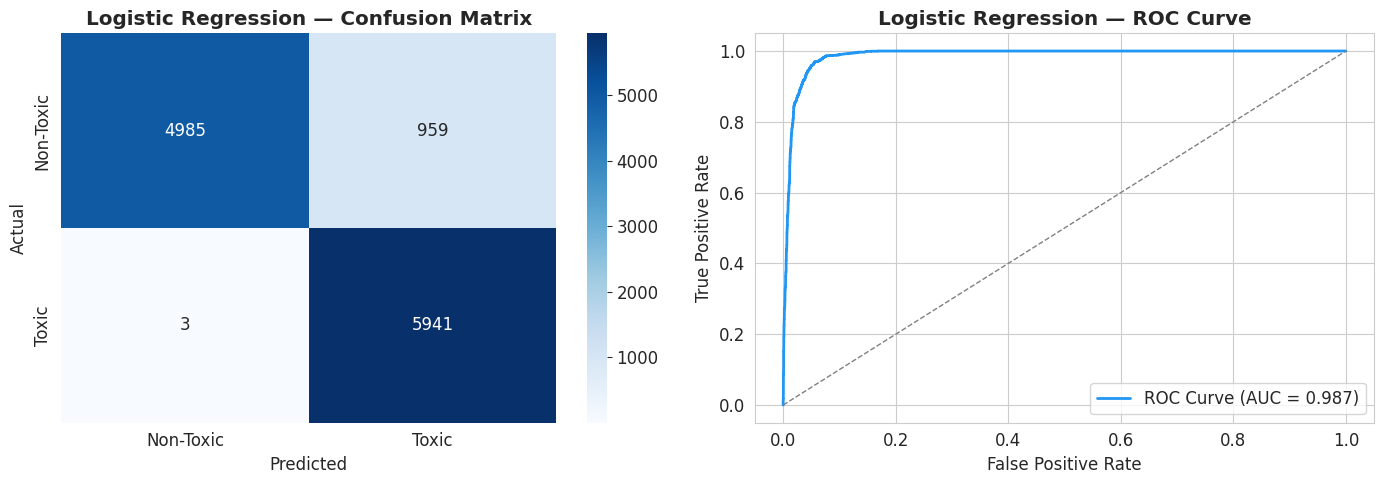

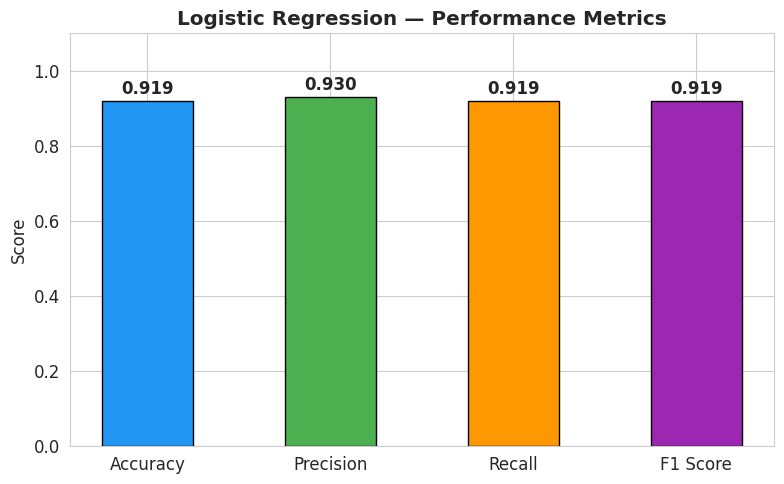

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Non-Toxic','Toxic'],
            yticklabels=['Non-Toxic','Toxic'])
axes[0].set_title('Logistic Regression — Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, lr_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#2196F3', lw=2,
             label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[1].plot([0,1],[0,1], color='gray', linestyle='--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Logistic Regression — ROC Curve', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/lr_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# Precision / Recall / F1 Bar Chart
fig, ax = plt.subplots(figsize=(8, 5))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values  = [lr_acc, lr_prec, lr_rec, lr_f1]
bars = ax.bar(metrics, values, color=['#2196F3','#4CAF50','#FF9800','#9C27B0'],
              edgecolor='black', width=0.5)
ax.set_ylim(0, 1.1)
ax.set_title('Logistic Regression — Performance Metrics', fontweight='bold')
ax.set_ylabel('Score')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/lr_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Sample to save time — increase if you have GPU
df_bert = df_balanced.sample(n=4000, random_state=42).reset_index(drop=True)
X_b_train, X_b_test, y_b_train, y_b_test = train_test_split(
    df_bert['clean_tweet'].values, df_bert['label'].values,
    test_size=0.2, random_state=42, stratify=df_bert['label']
)

class TweetDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = bert_tokenizer(list(texts), truncation=True,
                                         padding=True, max_length=128)
        self.labels = labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

train_loader = DataLoader(TweetDataset(X_b_train, y_b_train),
                          batch_size=16, shuffle=True)
test_loader  = DataLoader(TweetDataset(X_b_test,  y_b_test),
                          batch_size=16)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

bert_model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=2)
bert_model.to(device)

optimizer = AdamW(bert_model.parameters(), lr=2e-5)

# Track loss per epoch for plotting
bert_train_losses = []

bert_model.train()
for epoch in range(2):
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        outputs = bert_model(
            input_ids=batch['input_ids'].to(device),
            attention_mask=batch['attention_mask'].to(device),
            labels=batch['labels'].to(device)
        )
        outputs.loss.backward()
        optimizer.step()
        total_loss += outputs.loss.item()
    avg_loss = total_loss / len(train_loader)
    bert_train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/2 — Loss: {avg_loss:.4f}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device: cuda


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/2 — Loss: 0.4034
Epoch 2/2 — Loss: 0.1934


In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.metrics import confusion_matrix, roc_curve, auc

bert_model.eval()
bert_preds, bert_actuals, bert_probs = [], [], []

with torch.no_grad():
    for batch in test_loader:
        outputs = bert_model(
            input_ids=batch['input_ids'].to(device),
            attention_mask=batch['attention_mask'].to(device)
        )
        probs = torch.softmax(outputs.logits, dim=1)[:, 1]
        preds = torch.argmax(outputs.logits, dim=1)
        bert_preds.extend(preds.cpu().numpy())
        bert_actuals.extend(batch['labels'].numpy())
        bert_probs.extend(probs.cpu().numpy())

bert_acc  = accuracy_score(bert_actuals, bert_preds)
bert_prec, bert_rec, bert_f1, _ = precision_recall_fscore_support(
    bert_actuals, bert_preds, average='weighted')

print("── BERT ──")
print(f"Accuracy:  {bert_acc:.4f}")
print(f"Precision: {bert_prec:.4f}")
print(f"Recall:    {bert_rec:.4f}")
print(f"F1 Score:  {bert_f1:.4f}")
print()
print(classification_report(bert_actuals, bert_preds,
      target_names=['Non-Toxic', 'Toxic']))

── BERT ──
Accuracy:  0.8950
Precision: 0.8984
Recall:    0.8950
F1 Score:  0.8949

              precision    recall  f1-score   support

   Non-Toxic       0.94      0.85      0.89       406
       Toxic       0.86      0.94      0.90       394

    accuracy                           0.90       800
   macro avg       0.90      0.90      0.89       800
weighted avg       0.90      0.90      0.89       800



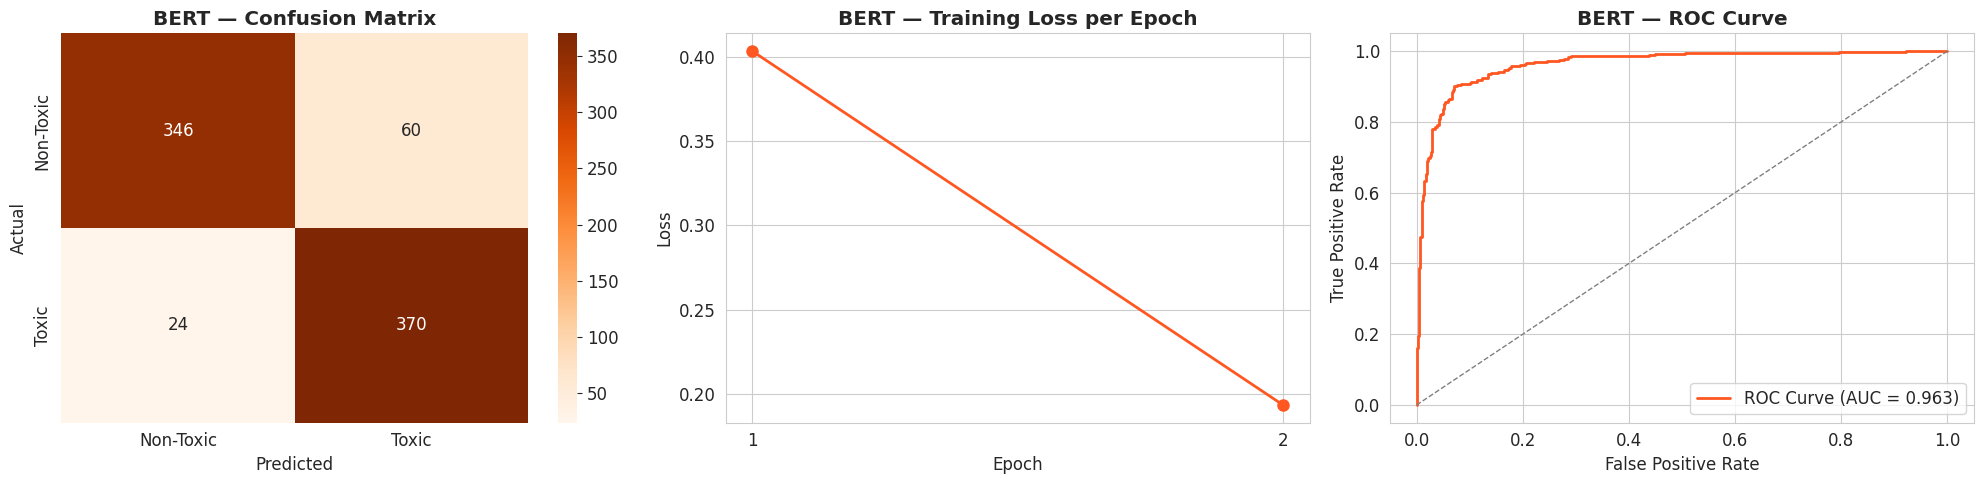

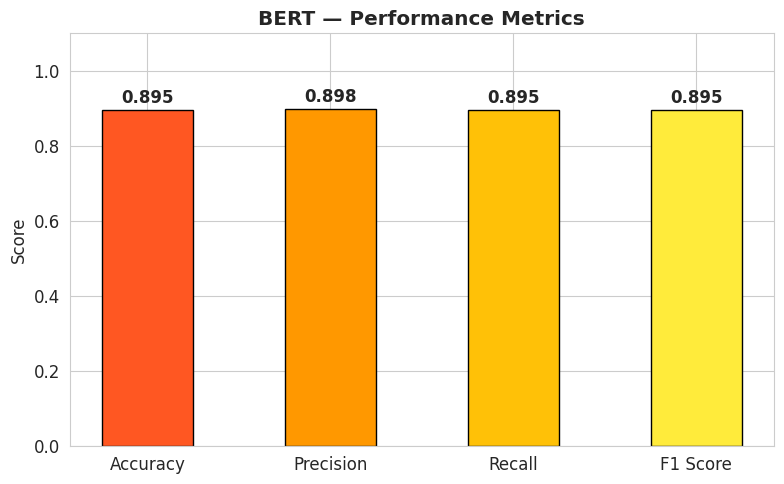

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Confusion Matrix
cm_bert = confusion_matrix(bert_actuals, bert_preds)
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['Non-Toxic','Toxic'],
            yticklabels=['Non-Toxic','Toxic'])
axes[0].set_title('BERT — Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Training Loss over Epochs
axes[1].plot(range(1, len(bert_train_losses)+1), bert_train_losses,
             marker='o', color='#FF5722', lw=2, markersize=8)
axes[1].set_title('BERT — Training Loss per Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_xticks(range(1, len(bert_train_losses)+1))

# ROC Curve
fpr_b, tpr_b, _ = roc_curve(bert_actuals, bert_probs)
roc_auc_b = auc(fpr_b, tpr_b)
axes[2].plot(fpr_b, tpr_b, color='#FF5722', lw=2,
             label=f'ROC Curve (AUC = {roc_auc_b:.3f})')
axes[2].plot([0,1],[0,1], color='gray', linestyle='--', lw=1)
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('BERT — ROC Curve', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig('/content/bert_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# Precision / Recall / F1 Bar Chart
fig, ax = plt.subplots(figsize=(8, 5))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values  = [bert_acc, bert_prec, bert_rec, bert_f1]
bars = ax.bar(metrics, values,
              color=['#FF5722','#FF9800','#FFC107','#FFEB3B'],
              edgecolor='black', width=0.5)
ax.set_ylim(0, 1.1)
ax.set_title('BERT — Performance Metrics', fontweight='bold')
ax.set_ylabel('Score')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/bert_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

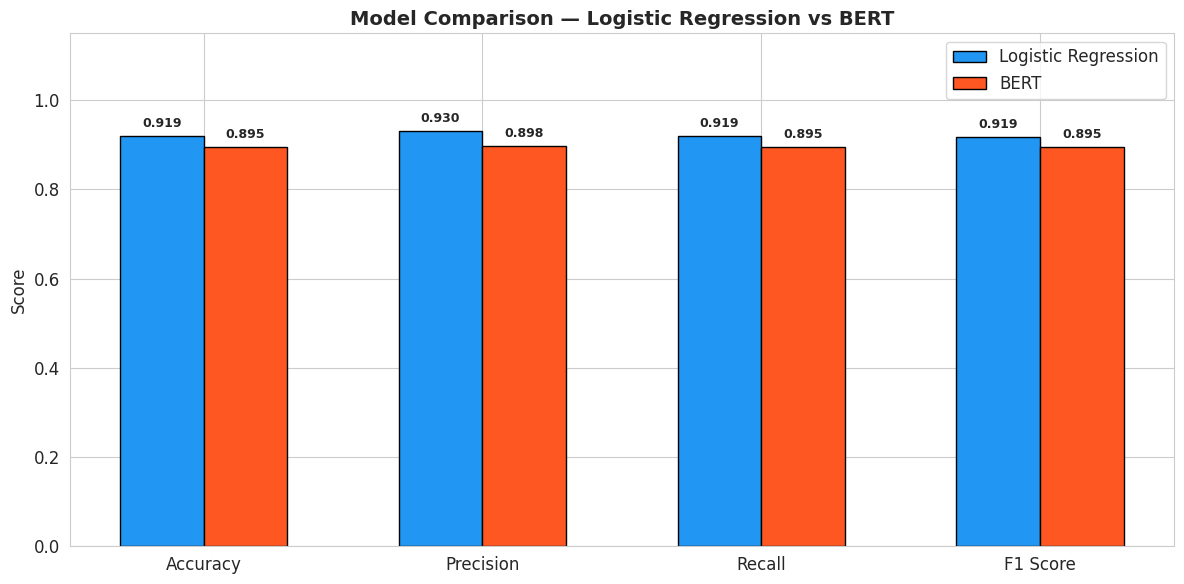


═════════════════════════════════════════════
Model                       Accuracy
═════════════════════════════════════════════
Logistic Regression           91.91%
BERT                          89.50%
═════════════════════════════════════════════


In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

models  = ['Logistic Regression', 'BERT']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
lr_vals   = [lr_acc,   lr_prec,   lr_rec,   lr_f1]
bert_vals = [bert_acc, bert_prec, bert_rec, bert_f1]

x = np.arange(len(metrics))
w = 0.3

bars1 = ax.bar(x - w/2, lr_vals,   w, label='Logistic Regression',
               color='#2196F3', edgecolor='black')
bars2 = ax.bar(x + w/2, bert_vals, w, label='BERT',
               color='#FF5722', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Logistic Regression vs BERT',
             fontsize=14, fontweight='bold')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "═"*45)
print(f"{'Model':<25} {'Accuracy':>10}")
print("═"*45)
print(f"{'Logistic Regression':<25} {lr_acc*100:>9.2f}%")
print(f"{'BERT':<25} {bert_acc*100:>9.2f}%")
print("═"*45)

In [ ]:
save_path = "/content/drive/MyDrive/ML 2026/Text Model/"
os.makedirs(save_path, exist_ok=True)

# Save LR + TF-IDF
pickle.dump(lr,    open(save_path + 'lr_model.pkl',         'wb'))
pickle.dump(tfidf, open(save_path + 'tfidf_vectorizer.pkl', 'wb'))

# Save BERT
bert_save = save_path + "bert_model/"
os.makedirs(bert_save, exist_ok=True)
bert_model.save_pretrained(bert_save)
bert_tokenizer.save_pretrained(bert_save)

# Save threshold config
with open(save_path + 'config.json', 'w') as f:
    json.dump({'lr_threshold': 0.3, 'bert_threshold': 0.5}, f)

print("✅ All models saved!")
print(f"  • {save_path}lr_model.pkl")
print(f"  • {save_path}tfidf_vectorizer.pkl")
print(f"  • {save_path}bert_model/")
print(f"  • {save_path}config.json")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ All models saved!
  • /content/drive/MyDrive/ML 2026/Text Model/lr_model.pkl
  • /content/drive/MyDrive/ML 2026/Text Model/tfidf_vectorizer.pkl
  • /content/drive/MyDrive/ML 2026/Text Model/bert_model/
  • /content/drive/MyDrive/ML 2026/Text Model/config.json


In [ ]:
from google.colab import files

files.download(save_path + 'lr_model.pkl')
files.download(save_path + 'tfidf_vectorizer.pkl')
files.download(save_path + 'config.json')

print("✅ Downloaded! BERT model stays in Google Drive.")
print(f"BERT path for Flask: {save_path}bert_model/")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded! BERT model stays in Google Drive.
BERT path for Flask: /content/drive/MyDrive/ML 2026/Text Model/bert_model/


In [ ]:
import shutil
shutil.copytree(
    "/content/drive/MyDrive/ML 2026/Text Model/bert_model",
    "/content/bert_model"
)

from google.colab import files
import os, zipfile

# Zip it first then download
with zipfile.ZipFile('/content/bert_model.zip', 'w') as z:
    for f in os.listdir('/content/bert_model'):
        z.write(f'/content/bert_model/{f}', f)

files.download('/content/bert_model.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>